A script for aligning brainreg output to probe survey and channel map

In [4]:
%load_ext autoreload
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.colors import Normalize
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
import matplotlib

from scipy.signal import find_peaks
import scipy.signal as signal

from JR_test_scripts.escape.escape_utils import load_hdir_cells, load_significant_cells
from behave_analysis.utils.creating_directories import make_directory
from kilosort_SGLX_funcs.ProbeLocations.ProbeLocation_utils import reorder_colors_for_contrast, extract_subject_and_date, estimate_firing_rate
from kilosort_SGLX_funcs.SGLXMetaToCoords import readMeta
from kilosort_SGLX_funcs.SGLXMetaToCoords import MetaToCoords

%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
"""Paths for JAL6 March 28th 2024"""

savepath = make_directory(r"Z:\Jasmine_Laurence\Histology\ChannelMap_to_Histology")

# brainreg output
brainreg = Path(r"Z:\Jasmine_Laurence\Histology\MouseID_006\brainreg\segmentation\atlas_space\tracks")

# probe survey
srvy = Path(r"Z:\Jasmine_Laurence\Experimental_data\JAL006\SvyPrb_2024-03-21T11.07.43_g0")

# channel map
meta = Path(r"Z:\Jasmine_Laurence\Experimental_data\JAL006\JAL006_shelter_barrier_flip_6_2024_03_28T10_54_20\barrier_flip6_g0\barrier_flip6_g0_imec0\barrier_flip6_g0_t0.imec0.ap.meta")

KS_path = Path(r"Z:\Jasmine_Laurence\Experimental_data\JAL006\JAL006_shelter_barrier_flip_6_2024_03_28T10_54_20\barrier_flip6_g0\barrier_flip6_g0_imec0\SI_KS_output\sorter_output")

from behave_analysis.database.Experiments.JAL006_ex import JAL6_28mar
experiment = [JAL6_28mar]
sesh_name = ["JAL6_28mar"]

In [3]:
"""Load in the brainreg track data"""
%autoreload 2
for i in range(4):
    track_path = Path(brainreg, f'track_{i}.csv')
    # Load in coordinates of track in CCF space (order - apdvml, origin - top, left, front voxel
    xyz = pd.read_csv(track_path)
    if i == 0:
        df = xyz
    else:
        df = pd.concat([df, xyz], ignore_index=True)

# plot the regions
regions = df['Region acronym']

region_codes, unique_regions = pd.factorize(regions)  # Convert regions to integer codes

region_by_probe = region_codes.reshape((4, 1000))
region_by_probe = np.fliplr(region_by_probe)

# Create a custom colormap with distinct colors for each region
tab20b_cmap = matplotlib.colormaps.get_cmap('tab20b')
tab20b_colors = [tab20b_cmap(i) for i in range(20)]
optimized_colors = reorder_colors_for_contrast(tab20b_colors, len(unique_regions))

# Create custom colormap
custom_cmap = mcolors.ListedColormap(optimized_colors)

# Create a normalization that maps each integer to a different color
norm = mcolors.Normalize(vmin=-0.5, vmax=len(unique_regions)-0.5)

fig, axs = plt.subplots(1, 1, figsize=(4, 8))
axs.imshow(region_by_probe.T, aspect='auto', cmap=custom_cmap, norm=norm, interpolation = "none")
axs.set_xticks([0,1,2,3])
axs.set_xticklabels(['Shank1', 'Shank2', 'Shank3', 'Shank4'])

for i, region in enumerate(unique_regions):
    if region == "Not found in brain":
        continue
    x_pos = np.argmax(np.sum(region_by_probe == i, axis=1))
    y_pos = np.mean(np.where(region_by_probe[x_pos,:] == i)[0])
    axs.text(x_pos, y_pos, region, ha='center', va='center', fontsize=8, color='black', weight = 'bold')
axs.invert_yaxis()

save = make_directory(savepath +  "\Brainreg_Map")
subject_id, survey_date = extract_subject_and_date(srvy)
name = subject_id + '_' + survey_date + ".png"
fig.savefig(Path(save, name), dpi=300, bbox_inches='tight')

plt.show()

In [5]:
"""Get the coordinates for the recorded banks"""
xCoord, yCoord, shankInd, connected, NchanTOT = MetaToCoords(metaFullPath=meta, outType=0, showPlot=False)

bank_positions = []
bank_shanks = []
for i in range(4): # iterate over shanks
    these_y = np.unique(yCoord[shankInd == i])
    bb = np.where(np.diff(these_y) > 15)[0] # find where the banks are discontinuous on the shank
    if len(bb) == 0:
        bank_positions.append([these_y[0], these_y[-1]])
        bank_shanks.append(i)
    else:
        bb = np.concatenate(([0], bb + 1, [len(these_y)-1]))
        for j in range(len(bb)-1):
            bank_positions.append([these_y[bb[j]], these_y[bb[j+1]-1]])
            bank_shanks.append(i)
bank_positions = np.array(bank_positions)
bank_shanks = np.array(bank_shanks)

In [6]:
"""Load and plot the probe survey"""
meta_files = list(srvy.glob('*.meta'))

# load the metadata
metadata = readMeta(meta_files[0])

# load the probe survey data
bin_file = list(srvy.glob('*.bin'))
bin_file = bin_file[0]

nChan = int(metadata['nSavedChans'])
nFileSamp = int(int(metadata['fileSizeBytes'])/(2*nChan))
print("nChan: %d, nFileSamp: %d" % (nChan, nFileSamp))
rawData = np.memmap(bin_file, dtype='int16', mode='r',
                    shape=(nChan, nFileSamp), offset=0, order='F')
data = rawData.T

# get the variance across channels
v = np.var(data, axis = 1)

nChan: 385, nFileSamp: 1970772


We now have 17 bank breakpoints and we should have 17


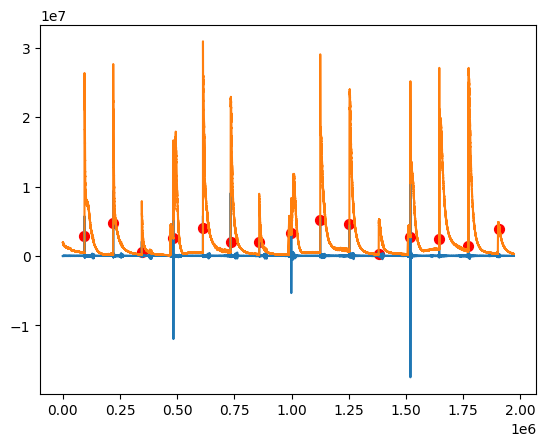

In [7]:
"""Find the threshold for identifying bank transitions"""
threshold = 100000
peaks, properties = find_peaks(np.diff(v), 
                               prominence=threshold, 
                               distance = int(metadata['imSampRate'])*int(metadata['imSvySecPerBnk']))
plt.plot(np.diff(v))
plt.plot(v)
plt.scatter(peaks, v[peaks], color='red', s=50)

# alternative for getting peaks
# peaks = np.where(np.diff(v)>1500000)[0]

bank_breakpoints = np.concatenate(([int(metadata['firstSample'])], peaks, [len(v)]))
bank_breakpoints_2 = bank_breakpoints[1:]
bank_breakpoints = np.concatenate(([int(metadata['firstSample'])],bank_breakpoints_2[np.diff(bank_breakpoints) > 1]))
print(f'We now have {len(bank_breakpoints)} bank breakpoints and we should have 17')

In [8]:
"""Extract the probe survey data for each bank"""

offset = int(metadata['firstSample'])
trim = int(metadata['imSampRate'])

# set up the butter
fs = float(metadata['imSampRate'])  # Sampling frequency in Hz from metadata
cutoff = [300, 7000]  # Cutoff frequency for low-pass filter in Hz (adjust as needed)
order = 4     # Filter order (higher = sharper cutoff but more ringing)
b, a = signal.butter(order, cutoff, btype='band', fs=fs)

all_variances = []
bank = 0
shank = 0
for (bb_start, bb_end) in zip(bank_breakpoints[:-1], bank_breakpoints[1:]):

    # stay far away from the edges of the banks
    bb_start += (offset + trim) 
    bb_end -= trim

    # get the bank data
    bank_data = data[int(bb_start):int(bb_end), :-1]
    
    # butter bandpass filter the data
    filtered_data = np.zeros_like(bank_data)
    for i in range(bank_data.shape[1]):
        filtered_data[:, i] = signal.filtfilt(b, a, bank_data[:, i])
    
    # get the channel cariances
    channel_variances = np.var(filtered_data, axis=0)

    # Compute mean for each channel (excluding the last TTL channel)
    channel_mean = np.mean(filtered_data, axis=0)

    # estimate firing rate
    firing_rates, all_spike_times = estimate_firing_rate(filtered_data, fs)
    
    all_variances.append({
        'bank': bank,
        'shank': shank,
        'variances': channel_variances.reshape((len(channel_variances)//2,2)), # two adjacent channels are the two contacts next to each other
        'means': channel_mean.reshape((len(channel_mean)//2,2)),
        'FR': firing_rates.reshape((len(channel_mean)//2,2)),
        'filtered_data': filtered_data.reshape((filtered_data.shape[0], filtered_data.shape[1]//2, 2)), # filtered data for this bank shaped as samples, channels, pads
    })

    bank += 1
    if bank == 4:
        bank = 0
        shank += 1

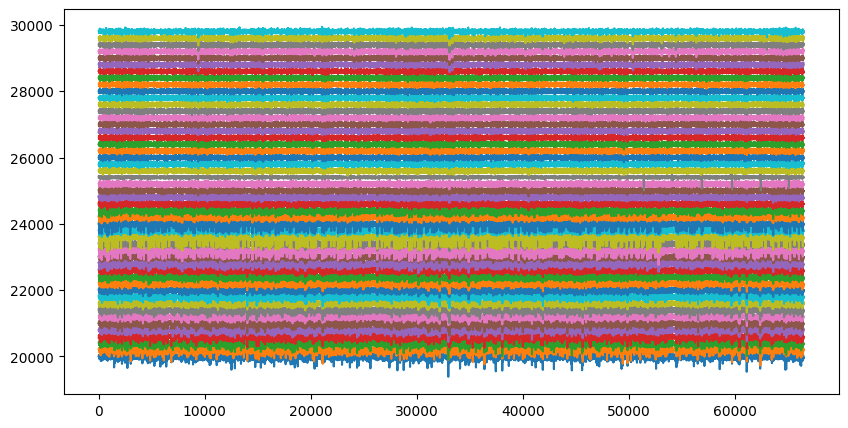

In [48]:
"""Inspect the filtered data in each bank of the survey"""
bank_n = 8 # 0,4,8,12 are the bottom ones that should definitely have spikes!

offset = 30000
# import scipy.signal as signal
fs = float(metadata['imSampRate'])  # Sampling frequency in Hz from metadata
cutoff = [300, 7000]  # Cutoff frequency for low-pass filter in Hz (adjust as needed)
order = 4     # Filter order (higher = sharper cutoff but more ringing)
b, a = signal.butter(order, cutoff, btype='band', fs=fs)

fig, axs = plt.subplots(1, 1, figsize=(10, 5))
# Choose a channel range to filter (50:100)
data_segment = data[int(bank_breakpoints[bank_n]+offset):int(bank_breakpoints[bank_n+1]-offset), :-1]

# Apply filter to each channel using filtfilt (zero-phase filtering)
filtered_data = np.zeros_like(data_segment)
use = np.arange(100,150)
for i in use:#range(50):#data_segment.shape[1]):
    filtered_data[:, i] = signal.filtfilt(b, a, data_segment[:, i])
# axs.imshow(filtered_data.T, aspect='auto', cmap='gray', interpolation='none')

for i in use:
    axs.plot(filtered_data[:,i]+(200*i))

In [9]:
"""Load in the cluster positions"""
%autoreload 2
# plot all good clusters or only clusters that are sig tuned to %escape

# # --- Load core data ---
clusters_inf = pd.read_csv(Path(KS_path, 'cluster_info.tsv'), sep='\t')
channel_positions = np.load(Path(KS_path, 'channel_positions.npy'))  # (n_clusters,)

# Extract the good clusters and their channels
if "group" in clusters_inf.columns:
    good_clusters = clusters_inf[clusters_inf['group'] == 'good']
else:
    good_clusters = clusters_inf[clusters_inf['KSLabel'] == "good"]
ch = good_clusters["ch"]

# load hdir cells
hdir = np.full((len(ch)), False)
hdir_sesh = load_hdir_cells(experiment,sesh_name)
hdir[hdir_sesh[0]] = True

# load cells sig tuned to %escape
sig = load_significant_cells(experiment[0])
sig = np.sum(sig, axis = 1) > 0

2025-04-14 16:16:51.547 | INFO     | behave_analysis.process.process:load_session:117 - All data has been moved from winstor to ceph so we always load ceph data now


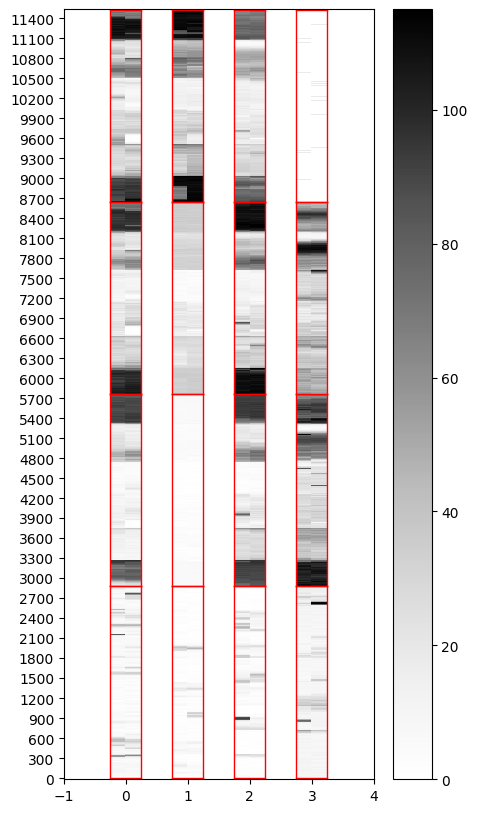

In [50]:
f,a = plt.subplots(1, 1, figsize=(5, 10))
shank = all_variances[0]['shank']
x = [-.25,.25]
for shank in range(4):
    for bank in all_variances:
        if bank['shank'] == shank:
            if bank['bank'] == 0:
                fr = bank['FR']
            else:
                fr = np.concatenate((fr, bank['FR']), axis = 0)
        if shank == 3:
            bank_id = bank['bank']
            bank_vertical_size = len(bank['FR'])
            bank_x_position = bank['shank']
            bank_y_start = bank_id * bank_vertical_size
            a.plot([bank_x_position-0.25, bank_x_position+0.25], [bank_y_start, bank_y_start], color='red', linewidth=1)  # Draw a line for the bank
            a.plot([bank_x_position-0.25, bank_x_position+0.25], [bank_y_start + bank_vertical_size, bank_y_start + bank_vertical_size], color='red', linewidth=1)  # Draw a line for the bank
            a.plot([bank_x_position-0.25, bank_x_position-0.25], [bank_y_start, bank_y_start + bank_vertical_size], color='red', linewidth=1)  # Draw a line for the bank
            a.plot([bank_x_position+0.25, bank_x_position+0.25], [bank_y_start, bank_y_start + bank_vertical_size], color='red', linewidth=1)  # Draw a line for the bank
    a.imshow(fr, aspect='auto', cmap='Greys', interpolation='none', extent = [x[0], x[1], fr.shape[0], 0])
    x = [x+1 for x in x]

a.set_ylim(-1, fr.shape[0]+1)
a.set_xlim(-1, 4)
tick_space_um = 300
a.set_yticks(np.arange(0, fr.shape[0], tick_space_um/15))
a.set_yticklabels(np.arange(0, fr.shape[0]*15, tick_space_um))
# show colorbar
cbar = f.colorbar(a.get_children()[0], ax=a)


Found contact 153.33333333333334 in shank 1 bank 0
0
Contact 153 in bank 0 shank 1


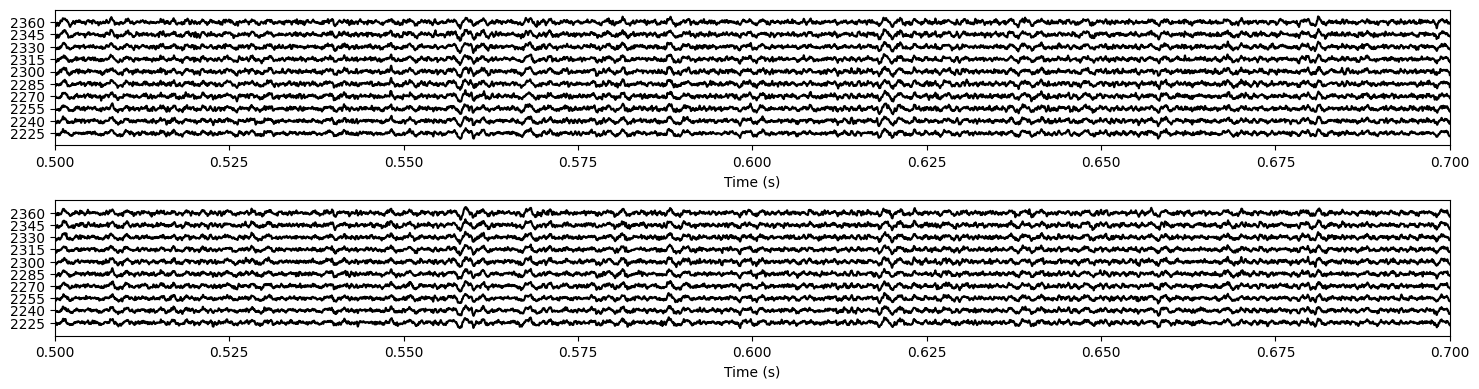

In [122]:
channel_spacing = 15
state = {
    'shank': 1,
    'depth_um': 2300,
    'x_range_s': [0.5, 0.7],
    'num_traces': 10,
    'spacing_au': 300
}

fig = plt.figure(figsize=(18, 12))
gs = gridspec.GridSpec(3, 2, width_ratios=[1, 1], height_ratios=[4, 1, 1])

contact_call = state['depth_um'] / channel_spacing
contact_num = 0
for shank in all_variances:
    if shank['shank'] == state['shank']:
        if (contact_call < (contact_num + shank['FR'].shape[0])) & (contact_call > contact_num):
            print(f"Found contact {contact_call} in shank {shank['shank']} bank {shank['bank']}")
            print(contact_num)
            c = int(contact_call - contact_num) # this is the number of the electrode in the bank
            print(f"Contact {c} in bank {shank['bank']} shank {shank['shank']}")
            # how many traces on either side
            if np.remainder(state['num_traces'], 2) == 0:
                num_trace = [int(state['num_traces'] / 2), int(state['num_traces'] / 2)]
            else:
                num_trace = [int(state['num_traces'] / 2) + 1, int(state['num_traces'] / 2)]
            for i in range(2):
                axs = fig.add_subplot(gs[1+i, :])
                x = np.arange(0, len(shank['filtered_data'][:, c, i])/30000, 1/30000)
                ytick = []
                yticklabel = []
                for cc, c_idx in enumerate(range(c-num_trace[0], c+num_trace[1])):
                    if c_idx < 0 or c_idx >= shank['filtered_data'].shape[1]:
                        continue
                    axs.plot(x, shank['filtered_data'][:, c_idx, i]+(state['spacing_au']*cc), color = 'black')
                    ytick.append(300*cc)
                    yticklabel.append(state['depth_um'] + (c_idx - c)*channel_spacing)
                axs.set_xlim(state['x_range_s'])
                axs.set_xlabel('Time (s)')
                axs.set_yticks(ytick)
                axs.set_yticklabels(yticklabel)
            break
        contact_num += shank['FR'].shape[0]

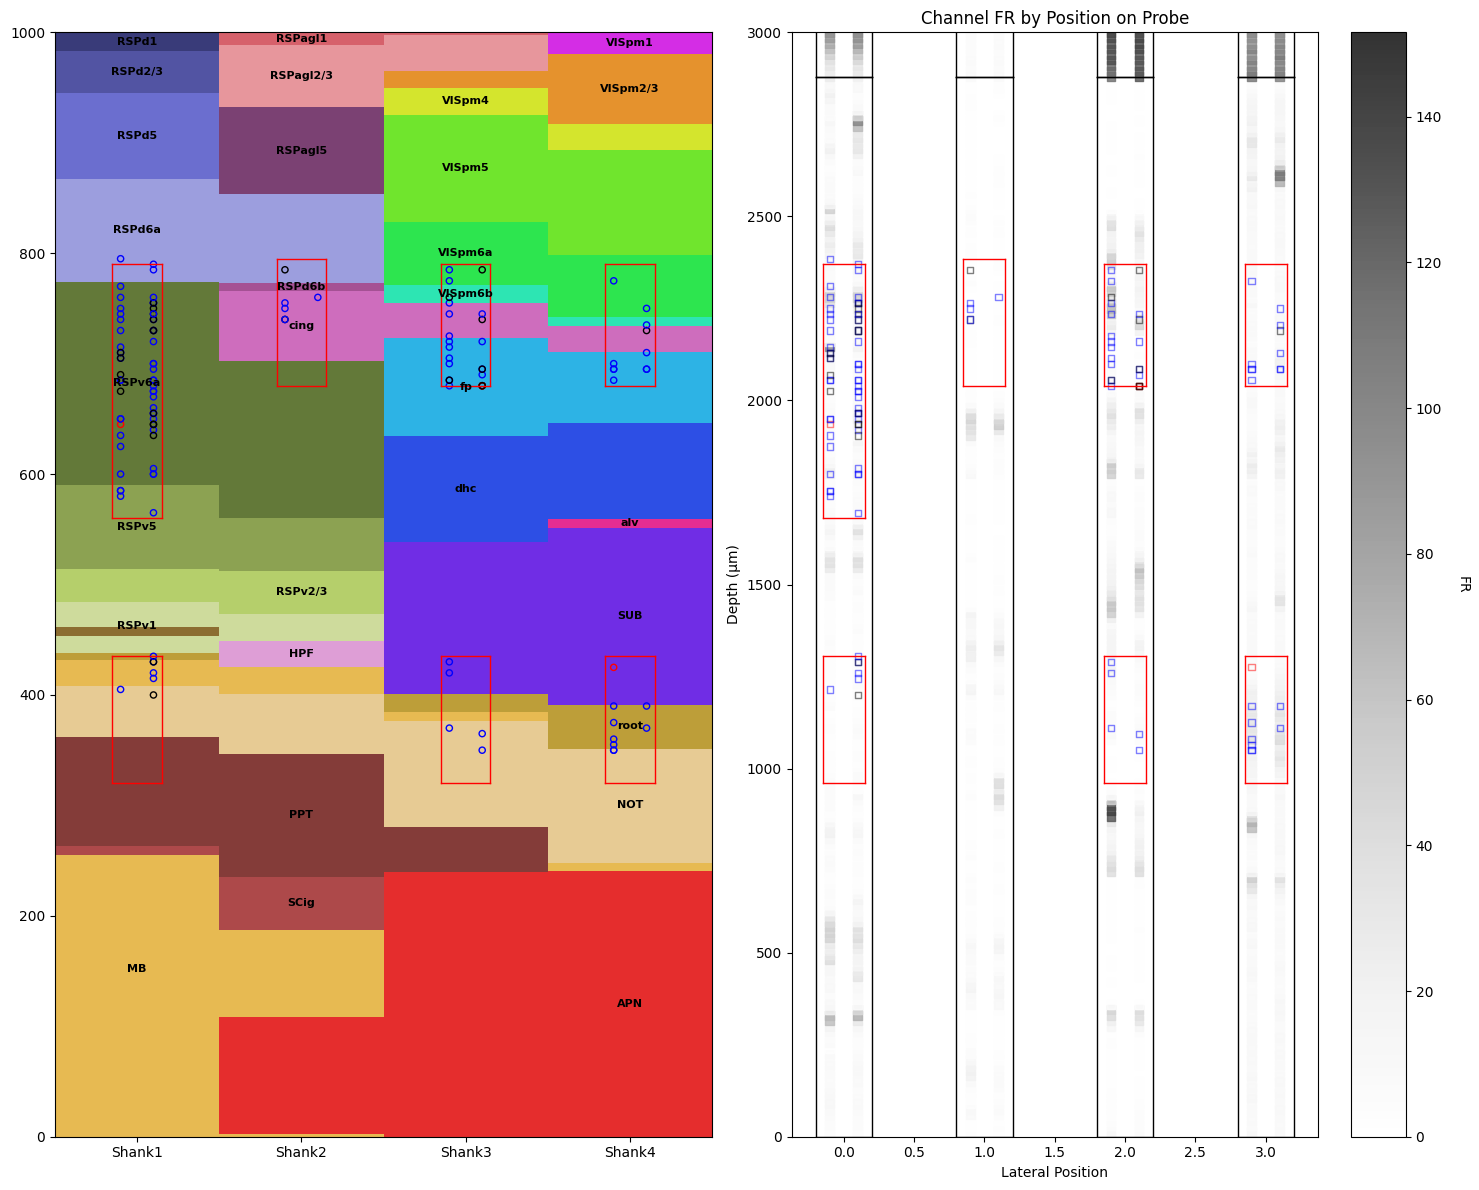

In [47]:
"""Create figure"""

plot = 'FR' # 'means' or 'variances' or 'FR'

fig = plt.figure(figsize=(15, 12))
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1])

ax = plt.subplot(gs[1])
# Define parameters for visualization
channel_spacing = 15  # µm spacing between channels
n_channels_per_bank = 384/2
bank_vertical_size = channel_spacing * n_channels_per_bank

# Collect all variances for colormap scaling
all_var_values = np.concatenate([bank[plot].flatten() for bank in all_variances])
# Make limits symmetric around zero for diverging colormap
abs_max = max(abs(np.min(all_var_values)), abs(np.max(all_var_values)))
vmin = -abs_max
vmax = abs_max
cmap = 'RdBu_r'  # Diverging colormap
if plot == 'FR':
    vmin = 0
    cmap = 'Greys'

# For each bank
for bank_data in all_variances:
    bank_id = bank_data['bank']
    variances = bank_data[plot]
    
    # Each bank starts from bottom (lower bank_id) to top
    bank_x_position = bank_data['shank']
    bank_y_start = bank_id * bank_vertical_size
    ax.plot([bank_x_position-0.2, bank_x_position+0.2], [bank_y_start, bank_y_start], color='black', linewidth=1)  # Draw a line for the bank
    ax.plot([bank_x_position-0.2, bank_x_position+0.2], [bank_y_start + bank_vertical_size, bank_y_start + bank_vertical_size], color='black', linewidth=1)  # Draw a line for the bank
    ax.plot([bank_x_position-0.2, bank_x_position-0.2], [bank_y_start, bank_y_start + bank_vertical_size], color='black', linewidth=1)  # Draw a line for the bank
    ax.plot([bank_x_position+0.2, bank_x_position+0.2], [bank_y_start, bank_y_start + bank_vertical_size], color='black', linewidth=1)  # Draw a line for the bank
    
    # Create positions for each channel
    y_positions = np.arange(bank_y_start, bank_y_start + bank_vertical_size, channel_spacing)
    
    # Plot variance values using scatter
    for idx, i in enumerate([-.1,.1]):
        scatter = ax.scatter(
            (np.ones(variances.shape[0])*bank_x_position)+i,  # All channels centered at x=0
            y_positions,               # y positions based on channel index
            c=variances[:,idx],               # color based on variance
            cmap=cmap,            # colormap
            marker='s',                # square markers
            s=40,                      # marker size
            alpha=0.8,                 # transparency
            norm= Normalize(vmin=vmin, vmax=vmax)
        )

# Add colorbar and labels
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label(plot, rotation=270, labelpad=20)
ax.set_xlabel('Lateral Position')
ax.set_ylim([0,3000])
ax.set_ylabel('Depth (µm)')
ax.set_title(f'Channel {plot} by Position on Probe')
ax.grid(False)

# add the channel map using bank positions
for (bs, bp) in zip(bank_shanks,bank_positions):
    ax.plot([bs-0.15, bs+0.15], [bp[1], bp[1]], color='red', linewidth=1)  # Draw a line for the bank
    ax.plot([bs-0.15, bs+0.15], [bp[0], bp[0]], color='red', linewidth=1)  # Draw a line for the bank
    ax.plot([bs-0.15, bs-0.15], [bp[0], bp[1]], color='red', linewidth=1)  # Draw a line for the bank
    ax.plot([bs+0.15, bs+0.15], [bp[0], bp[1]], color='red', linewidth=1)  # Draw a line for the bank

ch_x = [  0.,  32., 250., 282., 500., 532., 750., 782.]
bank_x = [-.1, .1, .9, 1.1, 1.9, 2.1, 2.9, 3.1]

# add the clusters!
for clu, i in enumerate(ch):
    x = bank_x[np.where(ch_x == channel_positions[i,0])[0][0]]
    color = 'black'
    if hdir[clu]:
        color = 'red'
    if sig[clu] & (not hdir[clu]):
        color = 'blue'
    ax.scatter(x, channel_positions[i,1], 
               facecolors='none',  # Makes markers hollow/unfilled
               edgecolors=color,  # Sets the edge color
               s=20, marker='s', alpha=0.5, linewidths=1)

ylims = ax.get_ylim()

"""add the region map next to it"""
scale = 3
axs = plt.subplot(gs[0])
axs.imshow(region_by_probe.T, aspect='auto', cmap=custom_cmap, norm=norm, interpolation = "none")
axs.set_xticks([0,1,2,3])
axs.set_xticklabels(['Shank1', 'Shank2', 'Shank3', 'Shank4'])

for i, region in enumerate(unique_regions):
    if region == "Not found in brain":
        continue
    x_pos = np.argmax(np.sum(region_by_probe == i, axis=1))
    y_pos = np.mean(np.where(region_by_probe[x_pos,:] == i)[0])
    axs.text(x_pos, y_pos, region, ha='center', va='center', fontsize=8, color='black', weight = 'bold')

# add the channel map using bank positions
for (bs, bp) in zip(bank_shanks,bank_positions):
    axs.plot([bs-0.15, bs+0.15], [bp[1]/scale, bp[1]/scale], color='red', linewidth=1)  # Draw a line for the bank
    axs.plot([bs-0.15, bs+0.15], [bp[0]/scale, bp[0]/scale], color='red', linewidth=1)  # Draw a line for the bank
    axs.plot([bs-0.15, bs-0.15], [bp[0]/scale, bp[1]/scale], color='red', linewidth=1)  # Draw a line for the bank
    axs.plot([bs+0.15, bs+0.15], [bp[0]/scale, bp[1]/scale], color='red', linewidth=1)  # Draw a line for the bank

bank_x = [-.1, .1, .9, 1.1, 1.9, 2.1, 2.9, 3.1]

# add the clusters!
for clu, i in enumerate(ch):
    color = 'black'
    if hdir[clu]:
        color = 'red'
    if sig[clu] & (not hdir[clu]):
        color = 'blue'
    x = bank_x[np.where(ch_x == channel_positions[i,0])[0][0]]
    axs.scatter(x, channel_positions[i,1]/scale, 
               facecolors='none',  # Makes markers hollow/unfilled
               edgecolors=color,  # Sets the edge color
               s=20, marker='o', linewidths=1)
    
# axs.set_ylim([ylims[0]/scale, ylims[1]/scale])
axs.set_ylim([0,3000/scale])

plt.tight_layout()
plt.show()